# ***18.09.2025 Exam Solution***

This notebook implements the solution suggested on the exam: deep neural network to predict whether a user will click on an advertisement based on behavioral and demographic information. LIME will be implemented at the end to explain a certain instance.

First I need to make results repeatable across runs and machines.

In [ ]:
SEED = 42

import os, random
import numpy as np

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)

try:
    tf.keras.utils.set_random_seed(SEED)
except AttributeError:
    tf.random.set_seed(SEED)

In [ ]:
!pip -q install scikeras==0.13.0

In [ ]:
import pandas as pd
import numpy as np
import pickle as pk
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import itertools
from sklearn.base import clone
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import AdamW
from scikeras.wrappers import KerasClassifier
import warnings
warnings.filterwarnings('ignore')
import re
from collections import Counter

# ***Data Loading and Inspection***

In [ ]:
!wget https://frasca.di.unimi.it/MLDNN/input_data.zip -O data.zip

with zipfile.ZipFile("data.zip", 'r') as zip_ref:
    zip_ref.extractall("unzipped_data")

with open("unzipped_data/input_data.pkl", "rb") as f:
    df = pk.load(f)

print(f"Dataset shape: {df.shape}")
print("\nDataset info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

--2025-10-02 12:21:13--  https://frasca.di.unimi.it/MLDNN/input_data.zip
Resolving frasca.di.unimi.it (frasca.di.unimi.it)... 159.149.130.139
Connecting to frasca.di.unimi.it (frasca.di.unimi.it)|159.149.130.139|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 73299 (72K) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]  71.58K   257KB/s    in 0.3s    

2025-10-02 12:21:14 (257 KB/s) - ‘data.zip’ saved [73299/73299]

Dataset shape: (953, 11)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  953 non-null    float64
 1   Age                       953 non-null    int64  
 2   Area Income               953 non-null    float64
 3   Daily Internet Usage      953 non-null    float64
 4   Ad Topic Line             953 non-null  

During the exam I thought a lot about **"Ad topic line"** feature, because logically it is important and I wanted to use the signal cue it contained. So I will inspect it now and see if my "bins" method is actually helpful

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

unique_topics = df["Ad Topic Line"].dropna().unique()
print(pd.Series(unique_topics))

pd.reset_option("display.max_rows")
pd.reset_option("display.max_colwidth")

0                           Cloned 5thgeneration orchestration
1                           Monitored national standardization
2                             Organic bottom-line service-desk
3                        Triple-buffered reciprocal time-frame
4                                Robust logistical utilization
5                              Sharable client-driven software
6                                   Enhanced dedicated support
7                                     Reactive local challenge
8                               Configurable coherent function
9                           Mandatory homogeneous architecture
10                              Centralized neutral neural-net
11               Team-oriented grid-enabled Local Area Network
12                       Centralized content-based focus group
13                            Synergistic fresh-thinking array
14                               Grass-roots coherent extranet
15                          Persistent demand-driven in

**CHANGE:** Initially, I planned to use **manual binning or K-means clustering for the Ad Topic Line feature**. However, after examining the actual data, I found that this column contains synthetically generated corporate buzzwords rather than genuine advertisement headlines.

This feature has extremely high cardinality and appears to be randomly generated text. While clustering techniques would technically work, they would only group words by lexical similarity rather than meaningful business categories. Similarly, a top-K approach would not provide interpretable insights.
So, **I am excluding the Ad Topic Line column from the data.**

# ***Preprocessing (point 2)***

In [ ]:
class TimestampFeatures(BaseEstimator, TransformerMixin):
    """Extract temporal features from timestamp"""
    def __init__(self, col="Timestamp"):
        self.col = col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.to_datetime(pd.Series(X[self.col]), errors="coerce", infer_datetime_format=True)
        month = s.dt.month.fillna(1).astype(int)
        hour = s.dt.hour.fillna(12).astype(int)
        year = s.dt.year.fillna(s.dt.year.median()).astype(int)

        # Create cyclical encoding for months
        month_sin = np.sin(2*np.pi*(month/12.0))
        month_cos = np.cos(2*np.pi*(month/12.0))

        # Binary daytime indicator (8 AM to 8 PM)
        is_daytime = ((hour >= 8) & (hour <= 20)).astype(int)

        # Return raw features: [month_sin, month_cos, is_daytime, year]
        return np.c_[month_sin, month_cos, is_daytime, year]

class SelectiveColumnScaler(BaseEstimator, TransformerMixin):
    """Apply scaler only to specific columns, leave others unchanged. This one is to scale Year only"""
    def __init__(self, columns_to_scale, scaler=None):
        self.columns_to_scale = columns_to_scale
        self.scaler = scaler if scaler else MinMaxScaler()

    def fit(self, X, y=None):
        if self.columns_to_scale:
            self.scaler.fit(X[:, self.columns_to_scale])
        return self

    def transform(self, X):
        X_copy = X.copy()
        if self.columns_to_scale:
            X_copy[:, self.columns_to_scale] = self.scaler.transform(X[:, self.columns_to_scale])
        return X_copy

class TopKOneHotEncoder(BaseEstimator, TransformerMixin):
    """High-cardinality top-K with 'other' bin (City, Country)"""
    def __init__(self, k=100):
        self.k = k
        self.topk_ = None
        self.ohe_ = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    def fit(self, X, y=None):
        ser = pd.Series(np.array(X).ravel())
        self.topk_ = set(ser.value_counts().head(self.k).index)
        mapped = ser.where(ser.isin(self.topk_), other="other").to_frame()
        self.ohe_.fit(mapped)
        return self
    def transform(self, X):
        ser = pd.Series(np.array(X).ravel())
        mapped = ser.where(ser.isin(self.topk_), other="other").to_frame()
        return self.ohe_.transform(mapped)

class SearchQueriesFlattener(BaseEstimator, TransformerMixin):
    """Just a technicality for Search Queries column. Simply convert list of lists to 2D numpy array"""
    def __init__(self, col="Search Queries"):
        self.col = col
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # Convert column of lists to 2D array
        return np.array(X[self.col].tolist())

Feature and target split

In [ ]:
DROP_COLS = ["Clicked on Ad", "Ad Topic Line"]  # label + unneccessary cloumn
y = df["Clicked on Ad"].astype(int).values
X = df.drop(columns=DROP_COLS).copy()

Train and test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Class balance train:", np.mean(y_train), " test:", np.mean(y_test))

Train size: (762, 9)  Test size: (191, 9)
Class balance train: 0.5  test: 0.5026178010471204


Now I will create pipelines for transforming data to feed it to MLP

In [ ]:
# === Preprocessing Pipelines ===
pipe_numeric_std = Pipeline([
    ("scale", StandardScaler())
])

pipe_age_minmax = Pipeline([
    ("scale", MinMaxScaler())
])

pipe_city_topk = Pipeline([
    ("topk_ohe", TopKOneHotEncoder(k=100))
])

pipe_country_topk = Pipeline([
    ("topk_ohe", TopKOneHotEncoder(k=50))
])

pipe_timestamp = Pipeline([
    ("extract", TimestampFeatures(col="Timestamp")),
    ("scale_year", SelectiveColumnScaler(columns_to_scale=[3], scaler=MinMaxScaler()))
])

pipe_search_queries = Pipeline([
    ("flatten", SearchQueriesFlattener(col="Search Queries"))
])

# === ColumnTransformer ===
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std",   pipe_numeric_std,   ["Daily Time Spent on Site", "Area Income", "Daily Internet Usage"]),
        ("age",       pipe_age_minmax,    ["Age"]),
        ("male",      "passthrough",      ["Male"]),
        ("city",      pipe_city_topk,     ["City"]),
        ("country",   pipe_country_topk,  ["Country"]),
        ("timestamp", pipe_timestamp,     ["Timestamp"]),
        ("searchq",   pipe_search_queries,["Search Queries"]),
    ],
    remainder="drop"
)

In [ ]:
# fit/transform
Xtr_enc = preprocessor.fit_transform(X_train)
Xte_enc = preprocessor.transform(X_test)

print("Encoded train shape:", Xtr_enc.shape)
print("Encoded test  shape:", Xte_enc.shape)
INPUT_DIM = Xtr_enc.shape[1]
print("INPUT_DIM:", INPUT_DIM)

Encoded train shape: (762, 461)
Encoded test  shape: (191, 461)
INPUT_DIM: 461


# ***MODEL (point 3 and 4A)***

I am proceeding exactly as stated in my written exam solution. The tabular features are fed to an MLP as a single input. The model's macro-structure is fixed (stacked blocks of Dense → BatchNorm → ReLU → Dropout with a final Dense(1) + Sigmoid for binary classification), while the *exact* number of such blocks—as well as dropout rate, batch size, weight regularization, and AdamW learning rate will be selected later via grid search with k-fold cross-validation.


In [ ]:
def MLP(hidden_units, dropout_rate, kernel_regularizer=None, name=None):
    """
    Block style exactly as in the exam text:
    [Dense -> BatchNorm -> ReLU -> Dropout] repeated for each 'units' in hidden_units.
    """
    seq = []
    for units in hidden_units:
        seq.append(layers.Dense(
            units,
            activation=None,                      # ReLU goes explicitly as a separate layer
            kernel_initializer="he_uniform",
            kernel_regularizer=kernel_regularizer)
        )
        seq.append(layers.BatchNormalization())
        seq.append(layers.ReLU())
        if dropout_rate and dropout_rate > 0:
            seq.append(layers.Dropout(dropout_rate))
    return keras.Sequential(seq, name=name)

class TabularMLPClassifier(keras.Model):
    """
    Pipeline:
      concatenated tabular vector (already preprocessed) -> MLP blocks -> Dense(1)+sigmoid
    Tunable HPs:
      - hidden_size, num_blocks
      - dropout_rate
      - weight_decay (L2)
    """
    def __init__(self, input_dim, hidden_size=128, num_blocks=2,
                 dropout_rate=0.2, weight_decay=1e-5, name="TabularMLPClassifier"):
        super().__init__(name=name)
        self.reg = (keras.regularizers.l2(weight_decay)
                    if weight_decay and weight_decay > 0 else None)
        self.mlp = MLP([hidden_size]*num_blocks, dropout_rate,
                       kernel_regularizer=self.reg, name="mlp_blocks")
        self.head = layers.Dense(1, activation="sigmoid",
                                 kernel_regularizer=self.reg, name="head")
        self.build((None, input_dim))  # for model.summary()

    def call(self, inputs, training=False):
        x = self.mlp(inputs, training=training)
        return self.head(x, training=training)

def compile_model(input_dim, hidden_size, num_blocks, dropout_rate, lr, weight_decay):
    model = TabularMLPClassifier(
        input_dim=input_dim,
        hidden_size=hidden_size,
        num_blocks=num_blocks,
        dropout_rate=dropout_rate,
        weight_decay=weight_decay
    )
    opt = AdamW(learning_rate=lr, weight_decay=weight_decay)
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ***Hyperparameters tuning (point 4b)***

This function runs a 3-fold stratified cross-validation loop on the preprocessed features

In [ ]:
def train_and_validate_cv(hidden_size, num_blocks, dropout_rate,
                          lr, weight_decay, batch_size,
                          X, y, epochs=30, k_folds=3, verbose=False, seed=SEED):

    tf.keras.utils.set_random_seed(seed)
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)

    f1s, accs = [], []
    last_model = None

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        model = compile_model(
            input_dim=X.shape[1],
            hidden_size=hidden_size,
            num_blocks=num_blocks,
            dropout_rate=dropout_rate,
            lr=lr,
            weight_decay=weight_decay
        )

        callbacks = [keras.callbacks.EarlyStopping(
            monitor="val_accuracy", mode="max",
            patience=5, restore_best_weights=True
        )]

        model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0 if not verbose else 1,
            callbacks=callbacks
        )

        probs = model.predict(X_va, batch_size=batch_size, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)

        f1s.append(f1_score(y_va, preds, zero_division=0))
        accs.append(accuracy_score(y_va, preds))
        last_model = model

        if verbose:
            print(f"Fold {fold}: F1={f1s[-1]:.4f}  Acc={accs[-1]:.4f}")

    return {
        "f1_mean":  float(np.mean(f1s)),
        "acc_mean": float(np.mean(accs)),
        "last_model": last_model,
    }

Due to the 5-minute runtime limit for the notebook, I use a compact grid that still tunes the key things (number of blocks, dropout rate, and AdamW learning rate). During development I ran a larger grid with 96 configurations and observed that the best models consistently came from the region kept here. Therefore I fix the less sensitive hyperparameters to stable defaults (hidden_size=256, batch_size=256, weight_decay=0) and search only over the most promising settings. Also I have to add LIME later, so I need to save time.

In [ ]:
# =========================
# Manual grid search — choose by CV F1
# =========================
import itertools

grid_num_blocks  = [1, 2]       # num blocks Dense->BN->ReLU->Dropout
grid_hidden_size = [256]  # layer width
grid_dropout     = [0.2, 0.5] # dropout rate
grid_lr          = [1e-3, 3e-4] #learning rate
grid_wd          = [0.0] #weight decay
grid_bs          = [256] #batch size

results = []
best = None

for L, H, dr, lr, wd, bs in itertools.product(
    grid_num_blocks, grid_hidden_size, grid_dropout, grid_lr, grid_wd, grid_bs
):
    cv_res = train_and_validate_cv(
        hidden_size=H, num_blocks=L, dropout_rate=dr,
        lr=lr, weight_decay=wd, batch_size=bs,
        X=Xtr_enc, y=y_train, epochs=30, k_folds=5, verbose=False
    )
    rec = {
        "blocks": L, "hidden": H, "dropout": dr, "lr": lr, "wd": wd, "batch": bs,
        "cv_f1": cv_res["f1_mean"], "cv_acc": cv_res["acc_mean"]
    }
    results.append(rec)
    if (best is None) or (rec["cv_f1"] > best["cv_f1"]):
        best = rec
    print(f"Config: L={L}, H={H}, dr={dr}, lr={lr}, wd={wd}, bs={bs} -> "
          f"cv_f1={rec['cv_f1']:.4f}  cv_acc={rec['cv_acc']:.4f}")

print("\nBest config (by CV F1):", best)

Config: L=1, H=256, dr=0.2, lr=0.001, wd=0.0, bs=256 -> cv_f1=0.9245  cv_acc=0.9252


Config: L=1, H=256, dr=0.2, lr=0.0003, wd=0.0, bs=256 -> cv_f1=0.9102  cv_acc=0.9108
Config: L=1, H=256, dr=0.5, lr=0.001, wd=0.0, bs=256 -> cv_f1=0.9444  cv_acc=0.9449
Config: L=1, H=256, dr=0.5, lr=0.0003, wd=0.0, bs=256 -> cv_f1=0.9144  cv_acc=0.9147
Config: L=2, H=256, dr=0.2, lr=0.001, wd=0.0, bs=256 -> cv_f1=0.9454  cv_acc=0.9462
Config: L=2, H=256, dr=0.2, lr=0.0003, wd=0.0, bs=256 -> cv_f1=0.9366  cv_acc=0.9369
Config: L=2, H=256, dr=0.5, lr=0.001, wd=0.0, bs=256 -> cv_f1=0.9469  cv_acc=0.9475
Config: L=2, H=256, dr=0.5, lr=0.0003, wd=0.0, bs=256 -> cv_f1=0.9404  cv_acc=0.9422

Best config (by CV F1): {'blocks': 2, 'hidden': 256, 'dropout': 0.5, 'lr': 0.001, 'wd': 0.0, 'batch': 256, 'cv_f1': 0.9468882662080397, 'cv_acc': 0.9474802201582389}


# ***Final Evaluation (point 5)***

Refit best config on the full train and evaluate on held-out test (F1 is the main reported metric; accuracy as secondary)

In [ ]:
best_model = compile_model(
    input_dim=INPUT_DIM,
    hidden_size=best["hidden"],
    num_blocks=best["blocks"],
    dropout_rate=best["dropout"],
    lr=best["lr"],
    weight_decay=best["wd"]
)

best_model.fit(
    Xtr_enc, y_train,
    epochs=30,
    batch_size=best["batch"],
    verbose=0
)

probs_test = best_model.predict(Xte_enc, batch_size=best["batch"], verbose=0).ravel()
preds_test = (probs_test >= 0.5).astype(int)

print("Test metrics (best config)")
print(" accuracy:", accuracy_score(y_test, preds_test))
print("      f1:", f1_score(y_test, preds_test, zero_division=0))

Test metrics (best config)
 accuracy: 0.9633507853403142
      f1: 0.9629629629629629


Now let's plot confusion matrix to see the results better

TN=93  FP=2  FN=5  TP=91


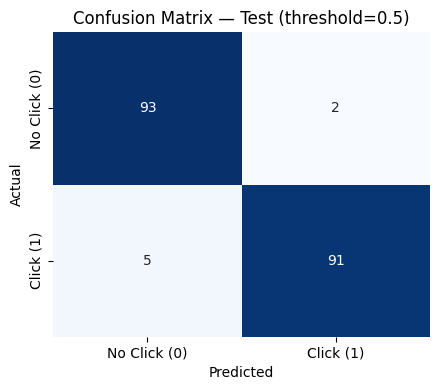

In [ ]:
from sklearn.metrics import confusion_matrix

preds_test = (probs_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, preds_test)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
            xticklabels=["No Click (0)", "Click (1)"],
            yticklabels=["No Click (0)", "Click (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test (threshold=0.5)")
plt.tight_layout()
plt.show()

The model is well-balanced with very few false positives (2) and few false negatives (5)

# ***LIME FOR EXPLAINABILITY (point 6)***

The LIME implementation in this project is significantly more complex than our lab's example, because this data is more complex. Please note, that I do not change what I wrote in the exam, logic stays exactly the same as I wrote. All of this is just technicality so the LIME Tabular can process the data. The explanations will be human-readable.

LIME Tabular can only work with numeric and categorical features and we have:

*   **Timestamp:** String format requiring conversion to numerical components
*   **Search Queries:** Lists of 300 integers that need special handling
*   **High-cardinality categorical variables** (City, Country) with hundreds of unique values

I will have to deal with them first and feed them to LIME in a right way.

In [ ]:
!pip -q install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


1) ***Timestamp*** → Month/Hour/Year: Converts "3/27/2016 0:53" into separate numeric components that LIME can independently vary.
2) ***Search Queries*** → 300 binary columns: Transforms [0,1,0,...] lists into individual search_0, search_1, etc. columns that LIME can flip independently

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

class_names = ['No Click', 'Click']

def prepare_data_for_lime(df):
    """Convert data to LIME-compatible format with easy conversion back"""
    df_lime = df.copy()

    # Timestamp: extract components that can easily be converted back
    timestamps = pd.to_datetime(df_lime['Timestamp'], errors='coerce')
    df_lime['Month'] = timestamps.dt.month.fillna(1)
    df_lime['Hour'] = timestamps.dt.hour.fillna(12)
    df_lime['Year'] = timestamps.dt.year.fillna(2016)

    # Search Queries: flatten to 300 binary columns
    search_data = np.array(df['Search Queries'].tolist())
    for i in range(300):
        df_lime[f'search_{i}'] = search_data[:, i]

    # Drop original complex columns
    df_lime = df_lime.drop(columns=['Timestamp', 'Search Queries'])

    return df_lime

def prepare_categorical_mapping(X_train_lime, X_test_lime):
    """Encode categorical columns for LIME (City, Country only - Male stays as 0/1)"""
    encoders = {}
    X_train_encoded = X_train_lime.copy()
    X_test_encoded = X_test_lime.copy()

    categorical_cols = ['City', 'Country']

    for col in categorical_cols:
        encoder = LabelEncoder()
        encoder.fit(X_train_lime[col])

        X_train_encoded[col] = encoder.transform(X_train_lime[col])

        # Handle unseen categories in test set
        X_test_encoded[col] = X_test_lime[col].map(
            dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
        ).fillna(0)  # Unseen categories get 0 (first category)

        encoders[col] = encoder

    return X_train_encoded, X_test_encoded, encoders

In [ ]:
# Prepare data
X_train_lime = prepare_data_for_lime(X_train)
X_test_lime = prepare_data_for_lime(X_test)

X_train_encoded, X_test_encoded, category_encoders = prepare_categorical_mapping(X_train_lime, X_test_lime)

LIME creates neighbor instances by modifying the LIME-formatted data, but my MLP model expects the original data format. This wrapper converts LIME's modifications back to the format my model understands.

In [ ]:
def predict_proba_for_lime(X_lime_format):
    """Convert LIME format back to original format and get predictions of blavk box model"""
    try:
        if isinstance(X_lime_format, np.ndarray):
            df_lime = pd.DataFrame(X_lime_format, columns=X_train_encoded.columns)
        else:
            df_lime = X_lime_format.copy()

        # Decode categorical variables back to strings
        df_decoded = df_lime.copy()

        for col in ['City', 'Country']:
            if col in category_encoders:
                encoder = category_encoders[col]
                encoded_values = df_lime[col].values.astype(int)
                decoded_values = []

                for val in encoded_values:
                    if 0 <= val < len(encoder.classes_):
                        decoded_values.append(encoder.classes_[val])
                    else:
                        decoded_values.append(encoder.classes_[0])  # Default to first

                df_decoded[col] = decoded_values

        # Convert back to original format
        df_original = df_decoded.copy()

        # Reconstruct Timestamp from Month, Hour, Year
        df_original['Timestamp'] = pd.to_datetime({
            'year': df_decoded['Year'].astype(int),
            'month': df_decoded['Month'].astype(int),
            'day': 1,
            'hour': df_decoded['Hour'].astype(int)
        }, errors='coerce').dt.strftime('%m/%d/%Y %H:%M')

        # Reconstruct Search Queries from 300 binary columns
        search_arrays = []
        for i in range(len(df_decoded)):
            search_vector = []
            for j in range(300):
                search_vector.append(int(df_decoded[f'search_{j}'].iloc[i]))
            search_arrays.append(search_vector)
        df_original['Search Queries'] = search_arrays

        # Remove LIME-specific columns
        columns_to_remove = ['Month', 'Hour', 'Year'] + [f'search_{i}' for i in range(300)]
        df_original = df_original.drop(columns=columns_to_remove)

        # Apply preprocessing pipeline
        X_preprocessed = preprocessor.transform(df_original)

        # Get predictions
        predictions = best_model.predict(X_preprocessed, verbose=0)

        # Convert to probabilities
        prob_class_1 = predictions.ravel()
        prob_class_0 = 1 - prob_class_1

        return np.column_stack([prob_class_0, prob_class_1])

    except Exception as e:
        print(f"Error in prediction wrapper: {e}")
        n_samples = X_lime_format.shape[0] if hasattr(X_lime_format, 'shape') else len(X_lime_format)
        return np.column_stack([np.full(n_samples, 0.5), np.full(n_samples, 0.5)])

Finally here I create explainer and it returns top 10 most influential features with their impact weights

In [ ]:
# Define categorical features for LIME
categorical_features = []
categorical_names = {}

for i, col in enumerate(X_train_encoded.columns):
    if col == 'City':
        categorical_features.append(i)
        categorical_names[i] = category_encoders['City'].classes_.tolist()
    elif col == 'Country':
        categorical_features.append(i)
        categorical_names[i] = category_encoders['Country'].classes_.tolist()
    elif col == 'Male':
        categorical_features.append(i)
        categorical_names[i] = ['Female', 'Male']
    elif col.startswith('search_'):
        categorical_features.append(i)
        categorical_names[i] = ['0', '1']

print(f"Categorical features: {len(categorical_features)} (City, Country, Male + 300 search)")

# Create LIME explainer
explainer = LimeTabularExplainer(
    X_train_encoded.values,
    feature_names=list(X_train_encoded.columns),
    class_names=class_names,
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    mode='classification',
    random_state=SEED
)

# Explain instance
instance_idx = 0
raw_instance = X_test.iloc[instance_idx]
encoded_instance = X_test_encoded.iloc[instance_idx]

print(f"\nAnalyzing user {instance_idx}")
print("=" * 40)

gender = 'Male' if raw_instance['Male'] == 1 else 'Female'
print(f"{raw_instance['Age']}-year-old {gender}")
print(f"From: {raw_instance['City']}, {raw_instance['Country']}")
print(f"Income: ${raw_instance['Area Income']:,.0f}")
print(f"Site time: {raw_instance['Daily Time Spent on Site']:.1f} min")

# Get prediction
actual_label = y_test[instance_idx]
pred_probs = predict_proba_for_lime(encoded_instance.values.reshape(1, -1))
predicted_prob = pred_probs[0][1]
predicted_class = 1 if predicted_prob >= 0.5 else 0

print(f"\nPrediction: {predicted_prob:.1%} → {class_names[predicted_class]}")
print(f"Actual: {class_names[actual_label]}")

# LIME explanation
explanation = explainer.explain_instance(
    encoded_instance.values,
    predict_proba_for_lime,
    num_features=10
)

print(f"\nKey factors:")
for i, (feature, weight) in enumerate(explanation.as_list()[:10], 1):
    print(f"{i:2d}. {feature}: {weight:+.3f}")

print("\nLIME analysis complete!")

Categorical features: 303 (City, Country, Male + 300 search)

Analyzing user 0
45-year-old Female
From: Williamsfort, Dominican Republic
Income: $38,645
Site time: 82.5 min

Prediction: 84.4% → Click
Actual: Click

Key factors:
 1. Daily Internet Usage <= 139.01: +0.424
 2. Daily Time Spent on Site > 78.63: -0.334
 3. Area Income <= 47366.03: +0.209
 4. Country=Dominican Republic: -0.157
 5. City=Adamsbury: +0.126
 6. search_187=1: -0.115
 7. search_11=0: -0.090
 8. search_43=0: -0.090
 9. search_206=0: +0.078
10. search_149=0: -0.063

LIME analysis complete!


**Conclusion**

This project showed how to work with LIME when your data isn't just simple numbers in a table. The main challenge was that LIME only handles basic features - numbers and categories. But we had complex data structures. So I ended up writing a bunch of conversion code to get readable explanations like "Country=Tunisia" instead of meaningless things like "feature_42: +0.3".

Now I understand why explainable AI requires so much extra engineering work in real projects - data is rarely in the format that off-the-shelf tools expect. The preprocessing pipeline ended up being more complex than the actual model, but that's apparently normal when you need human-interpretable explanations.